In [109]:

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import math, time, os, pickle
import matplotlib.pyplot as plt

class NAC(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()
        #review this
        self.W_hat = nn.Parameter(torch.Tensor(in_features, out_features))
        self.M_hat = nn.Parameter(torch.Tensor(in_features, out_features))
        #self.W_hat = nn.Parameter(torch.Tensor(out_features, in_features))
        #self.M_hat = nn.Parameter(torch.Tensor(out_features, in_features))
        self.reset_parameters()
    def reset_parameters(self):
        nn.init.uniform_(self.W_hat, -1e-2, 1e-2)
        nn.init.uniform_(self.M_hat, -1e-2, 1e-2)

    def forward(self, x):
        W = torch.tanh(self.W_hat) * torch.sigmoid(self.M_hat)
        return torch.matmul(x, W)

class NALU(nn.Module):
    def __init__(self, in_features, out_features, dependent_g=True):
        super().__init__()
        self.W_hat = nn.Parameter(torch.Tensor(in_features, out_features))
        self.M_hat = nn.Parameter(torch.Tensor(in_features, out_features))
        self.dependent_g = dependent_g
        self.eps = 1e-10

        if dependent_g:
            self.G = nn.Parameter(torch.Tensor(in_features, out_features))
        else:
            self.G = nn.Parameter(torch.Tensor(out_features))

        self.reset_parameters()

    def reset_parameters(self):
        nn.init.uniform_(self.W_hat, -1e-2, 1e-2)
        nn.init.uniform_(self.M_hat,-1e-2, 1e-2)
        nn.init.uniform_(self.G, -1e-2, 1e-2)

    def forward(self, x):
        W = torch.tanh(self.W_hat) * torch.sigmoid(self.M_hat)

        # Additive path
        a = torch.matmul(x, W)

        # Multiplicative path
        x_log = torch.log(torch.abs(x) + self.eps)
        m = torch.exp(torch.matmul(x_log, W))

        # Gating
        if self.dependent_g:
            g = torch.sigmoid(torch.matmul(x, self.G))
        else:
            g = torch.sigmoid(self.G)

        return g * a + (1 - g) * m

class NALU2M(nn.Module):
    def __init__(self, in_features, out_features, dependent_g=True):
        super().__init__()
        self.W0_hat = nn.Parameter(torch.Tensor(in_features, out_features))
        self.M0_hat = nn.Parameter(torch.Tensor(in_features, out_features))
        self.W1_hat = nn.Parameter(torch.Tensor(in_features, out_features))
        self.M1_hat = nn.Parameter(torch.Tensor(in_features, out_features))
        self.dependent_g = dependent_g
        self.G = nn.Parameter(torch.Tensor(in_features, out_features) if dependent_g else torch.Tensor(out_features))
        self.eps = 1e-10
        self.reset_parameters()

    def reset_parameters(self):
        for p in [self.W0_hat, self.M0_hat, self.W1_hat, self.M1_hat, self.G]:
            nn.init.uniform_(p, -1e-2, 1e-2)

    def forward(self, x):
        W0 = torch.tanh(self.W0_hat) * torch.sigmoid(self.M0_hat)  # shape (in, out)
        W1 = torch.tanh(self.W1_hat) * torch.sigmoid(self.M1_hat)

        a = torch.matmul(x, W0)  # like nd.dot(x, W0)
        log_x = torch.log(torch.clamp(torch.abs(x), min=self.eps))
        m = torch.exp(torch.matmul(log_x, W1))
        #m = torch.exp(torch.matmul(torch.log(torch.abs(x) + self.eps), W1))

        if self.dependent_g:
            g = torch.sigmoid(torch.matmul(x, self.G))
        else:
            g = torch.sigmoid(self.G)
        
        g = torch.clamp(torch.sigmoid(torch.matmul(x, self.G)), 0.01, 0.99)


        return g * a + (1 - g) * m

class NALUIG(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()
        self.W0_hat = nn.Parameter(torch.Tensor(in_features, out_features))  # MATCH MXNet
        self.M0_hat = nn.Parameter(torch.Tensor(in_features, out_features))
        self.G = nn.Parameter(torch.Tensor(out_features))  # Independent gate
        self.eps = 1e-10
        self.reset_parameters()

    def reset_parameters(self):
        nn.init.uniform_(self.W0_hat, -1e-2, 1e-2)
        nn.init.uniform_(self.M0_hat, -1e-2, 1e-2)
        nn.init.uniform_(self.G, -1e-2, 1e-2)

    def forward(self, x):
        W0 = torch.tanh(self.W0_hat) * torch.sigmoid(self.M0_hat)  # shape: (in, out)
        a = torch.matmul(x, W0)
        m = torch.exp(torch.matmul(torch.log(torch.abs(x) + self.eps), W0))

        g = torch.sigmoid(self.G)
        if g.dim() == 1:
          g = g.unsqueeze(0)  # shape: (out,)
        return g * a + (1 - g) * m

class NALU2MIG(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()
        self.W0_hat = nn.Parameter(torch.Tensor(in_features, out_features))
        self.M0_hat = nn.Parameter(torch.Tensor(in_features, out_features))
        self.W1_hat = nn.Parameter(torch.Tensor(in_features, out_features))
        self.M1_hat = nn.Parameter(torch.Tensor(in_features, out_features))
        self.G = nn.Parameter(torch.Tensor(out_features))  # Independent gate
        self.eps = 1e-10
        self.reset_parameters()

    def reset_parameters(self):
        for p in [self.W0_hat, self.M0_hat, self.W1_hat, self.M1_hat, self.G]:
            nn.init.uniform_(p, -1, 1)

    def forward(self, x):
        # Compute W0 and W1 like NAC logic
        W0 = torch.tanh(self.W0_hat) * torch.sigmoid(self.M0_hat)
        W1 = torch.tanh(self.W1_hat) * torch.sigmoid(self.M1_hat)

        # Linear and multiplicative pathways (no transposing!)
        a = torch.matmul(x, W0)
        m = torch.exp(torch.matmul(torch.log(torch.abs(x) + self.eps), W1))

        # Independent gate (broadcasts automatically)
        g = torch.sigmoid(self.G)
        if g.dim() == 1:
            g = g.unsqueeze(0)
        return g * a + (1 - g) * m

class NALU2MIG_improved(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()
        self.W0_hat = nn.Parameter(torch.Tensor(in_features, out_features))
        self.M0_hat = nn.Parameter(torch.Tensor(in_features, out_features))
        self.W1_hat = nn.Parameter(torch.Tensor(in_features, out_features))
        self.M1_hat = nn.Parameter(torch.Tensor(in_features, out_features))
        self.G = nn.Parameter(torch.Tensor(out_features))  # Independent gate
        self.eps = 1e-10
        self.reset_parameters()

    def reset_parameters(self):
        for p in [self.W0_hat, self.M0_hat, self.W1_hat, self.M1_hat, self.G]:
            nn.init.uniform_(p, -1, 1)

    def forward(self, x):
        # Compute W0 and W1 like NAC logic
        W0 = torch.tanh(self.W0_hat) * torch.sigmoid(self.M0_hat)
        W1 = torch.tanh(self.W1_hat) * torch.sigmoid(self.M1_hat)

        # Linear and multiplicative pathways (no transposing!)
        a = torch.matmul(x, W0)
        #x_safe = torch.clamp(torch.abs(x), min=self.eps)
        x_safe = F.softplus(x) + self.eps
        m = torch.exp(torch.matmul(torch.log1p(x_safe), W1))

        # Independent gate (broadcasts automatically)
        g = torch.sigmoid(self.G)
        if g.dim() == 1:
            g = g.unsqueeze(0)
        return g * a + (1 - g) * m




class SharedNALU(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()
        self.W_hat = nn.Parameter(torch.Tensor(in_features, out_features))
        self.M_hat = nn.Parameter(torch.Tensor(in_features, out_features))
        self.G = nn.Parameter(torch.Tensor(out_features))  # Independent gate
        self.eps = 1e-7
        self.reset_parameters()

    def reset_parameters(self):
        nn.init.uniform_(self.W_hat, -1e-2, 1e-2)
        nn.init.uniform_(self.M_hat, -1e-2, 1e-2)
        nn.init.uniform_(self.G, -1e-2, 1e-2)

    def forward(self, x):
        W = torch.tanh(self.W_hat) * torch.sigmoid(self.M_hat)  # Effective weight
        g = torch.sigmoid(self.G).unsqueeze(0)  # shape [1, out_features]

        a = torch.matmul(x, W)
        m = torch.exp(torch.matmul(torch.log(torch.abs(x) + self.eps), W))

        return g * a + (1 - g) * m


class FactorizedNALU(nn.Module):
    def __init__(self, in_features, out_features, rank=10):
        super().__init__()
        self.U = nn.Linear(in_features, rank, bias=False)
        self.V = nn.Linear(rank, out_features, bias=False)
        self.G = nn.Parameter(torch.Tensor(out_features))  # Independent gate
        self.eps = 1e-7
        self.reset_parameters()

    def reset_parameters(self):
        nn.init.uniform_(self.U.weight, -1e-2, 1e-2)
        nn.init.uniform_(self.V.weight, -1e-2, 1e-2)
        nn.init.uniform_(self.G, -1e-2, 1e-2)

    def forward(self, x):
        g = torch.sigmoid(self.G).unsqueeze(0)  # shape [1, out_features]
        a = self.V(self.U(x))
        log_x = torch.log(torch.abs(x) + self.eps)
        m = torch.exp(self.V(self.U(log_x)))
        return g * a + (1 - g) * m


class FactorizedNALU_improved(nn.Module):
    def __init__(self, in_features, out_features, rank=10):
        super().__init__()
        self.Ua = nn.Linear(in_features, rank, bias=False)
        self.Va = nn.Linear(rank, out_features, bias=False)
        self.Um = nn.Linear(in_features, rank, bias=False)
        self.Vm = nn.Linear(rank, out_features, bias=False)
        #self.G = nn.Linear(in_features, out_features)
        self.G = nn.Parameter(torch.Tensor(out_features))
        self.eps = 1e-7
        self.reset_parameters()

    def reset_parameters(self):
        nn.init.uniform_(self.G, -1e-2, 1e-2)
        for layer in [self.Ua, self.Va, self.Um, self.Vm]:
            nn.init.uniform_(layer.weight, -1e-2, 1e-2)
            if layer.bias is not None:
                nn.init.zeros_(layer.bias)

    def forward(self, x):
        #g = torch.sigmoid(self.G(x))
        g = torch.sigmoid(self.G).unsqueeze(0)
        a = self.Va(self.Ua(x))
        log_x = torch.log1p(F.softplus(x))  # more stable
        m = torch.exp(self.Vm(self.Um(log_x)))
        return g * a + (1 - g) * m


class NMU(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()
        self.mask_logits = nn.Parameter(torch.Tensor(out_features, in_features))
        self.reset_parameters()

    def reset_parameters(self):
        nn.init.constant_(self.mask_logits, 0.0)

    def forward(self, x):
        mask = torch.sigmoid(self.mask_logits)  # shape [out_features, in_features]
        x = x.unsqueeze(1)  # shape [batch, 1, in_features]
        masked_x = x * mask.unsqueeze(0) + (1 - mask.unsqueeze(0))  # mask applied
        prod = torch.prod(masked_x, dim=-1)  # product across features
        return prod  # shape [batch, out_features]


class HybridArithmeticLayer(nn.Module):
    def __init__(self, in_features, out_features, rank=10):
        super().__init__()
        self.add_path = FactorizedNALU(in_features, out_features, rank=rank)
        self.mul_path = NMU(in_features, out_features)
        self.gate = nn.Parameter(torch.Tensor(out_features))
        self.reset_parameters()

    def reset_parameters(self):
        nn.init.uniform_(self.gate, -1e-2, 1e-2)

    def forward(self, x):
        g = torch.sigmoid(self.gate).unsqueeze(0)  # shape [1, out_features]
        a = self.add_path(x)
        m = self.mul_path(x)
        return g * a + (1 - g) * m
    

class SafeDivide(nn.Module):
    def __init__(self, eps=1e-3):
        super().__init__()
        self.eps = eps

    def forward(self, a, b):
        return a / (torch.sign(b) * torch.clamp(torch.abs(b), min=self.eps))
    
class HybridArithmeticModel(nn.Module):
    def __init__(self, in_features, hidden_dim, out_features=1, use_safe_div=False, use_nmu=False):
        super().__init__()
        self.use_safe_div = use_safe_div

        self.relu_path = nn.Sequential(
            nn.Linear(in_features, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, out_features)
        ) if not use_nmu else nn.Sequential(
            NMU(in_features, hidden_dim),
            NMU(hidden_dim, out_features)
        )

        self.nalu_path = nn.Sequential(
            NALU2M(in_features, hidden_dim),
            NALU2M(hidden_dim, out_features)
        )

        self.safe_div = SafeDivide()

    def forward(self, x):
        out_relu = self.relu_path(x)
        out_nalu = self.nalu_path(x)

        out = 0.5 * (out_relu + out_nalu)  # blend both paths

        if self.use_safe_div:
            # Assume input is shaped [batch_size, input_dim]
            a = x[:, :x.shape[1] // 2]
            b = x[:, x.shape[1] // 2:]
            a_sum = torch.sum(a, dim=1, keepdim=True)
            b_sum = torch.sum(b, dim=1, keepdim=True)
            out = self.safe_div(a_sum, b_sum)

        return out


In [110]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import math, time, os, pickle
import matplotlib.pyplot as plt

# === NALU and NAC definitions (same as before) ===
# ... [Omitted for brevity — unchanged NALU classes] ...

# === Dataset Generation ===


functions = {
    'a + b':   lambda a, b: a + b,
    'a - b':   lambda a, b: a - b,
    'a x b':   lambda a, b: a * b,
    'a / b':   lambda a, b: a / b,
    'a ^ 2':   lambda a, b: a**2,
    'sqrt(a)': lambda a, b: np.sqrt(a),
}

activations = {
    'ReLU':    nn.ReLU(),
    'Sigmoid': nn.Sigmoid(),
}

IN_DIM = 100
#IN_DIM = 2
HIDDEN_DIM = 8
N, M = 0, 10
P, Q = 70, 100

#N, M = 0, 1
#P, Q = 1, 2
best_models = {}

def load_data(op, scale, train_size, test_size):
    import time
    print(f"[load_data] Start loading data for op={op}, scale={scale}, train_size={train_size}, test_size={test_size}")
    t0 = time.time()
    np.random.seed(0)
    func = functions[op]

    if op == 'sqrt(a)':
    # Generate non-negative training data
        x_train = np.random.uniform(0, scale * 10, size=(train_size, 1))
        x_train = (x_train - x_train.mean(axis=0)) / x_train.std(axis=0)
        y_train = func(x_train[:, 0], np.zeros_like(x_train[:, 0]))  # b is dummy
        y_max = np.max(np.abs(y_train))
        y_train /= y_max

        def sample_sqrt_test(scale_factor, condition, max_samples):
            x_list, y_list, count = [], [], 0
            attempts = 0
            max_attempts = 1000
            while count < max_samples and attempts < max_attempts:
                x = np.random.uniform(0, scale * scale_factor * 10, size=(max_samples, 1))
                a = x[:, 0]
                b = np.zeros_like(a)  # dummy b
                y = func(a, b) / y_max
                mask = condition(a, b, y)
                x_list.append(x[mask])
                y_list.append(y[mask])
                count += np.sum(mask)
                attempts += 1
            return np.concatenate(x_list)[:max_samples], np.concatenate(y_list)[:max_samples]

        in_cond = lambda a, b, y: (a < np.max(x_train))
        out_cond = lambda a, b, y: (a >= np.max(x_train))

        x_test_i, y_test_i = sample_sqrt_test(1, in_cond, test_size)
        x_test_e, y_test_e = sample_sqrt_test(4, out_cond, test_size)

        return (
            x_train.astype(np.float32), y_train.astype(np.float32),
            x_test_i.astype(np.float32), y_test_i.astype(np.float32),
            x_test_e.astype(np.float32), y_test_e.astype(np.float32)
        )
    
    x_train = np.random.uniform(0, scale, size=(train_size, IN_DIM))
    x_train /= scale
    y_train = func(np.sum(x_train[:, N:M], axis=1), np.sum(x_train[:, P:Q], axis=1))
    print(f"[load_data] x_train/y_train generated in {time.time() - t0:.2f} seconds")


    a_max = np.max(np.sum(x_train[:, N:M], axis=1))
    b_max = np.max(np.sum(x_train[:, P:Q], axis=1))
    if op == 'a / b':
        
        b_max = np.clip(b_max, 0.1, None)  # Must come before normalization to avoid zero
        
    
    y_max = np.max(np.abs(y_train))
    if y_max <= 0:
        raise ValueError(f"Invalid y_max={y_max:.4f}. Cannot normalize by non-positive value.")
    y_train = y_train / y_max
    print(f"a_max={a_max:.4f}, b_max={b_max:.4f}, y_max={y_max:.4f}")
    def sample_test(scale_factor, condition, max_samples):
        x_list, y_list, count = [], [], 0
        t1 = time.time()
        max_attempts = 1000
        attempts = 0
        while count < max_samples and attempts < max_attempts:
            
            #print(f'[load data] With current count={count} and {max_samples}')
            x = np.random.uniform(0, scale * scale_factor, size=(max_samples, IN_DIM))
            #x /= scale * scale_factor
            x = (x - x.mean(axis=0)) / x.std(axis=0)
            a = np.sum(x[:, N:M], axis=1)
            b = np.sum(x[:, P:Q], axis=1)
            if op == 'a / b':
                
                b = np.clip(b, 0.1, None)  # Must come before normalization to avoid zero
                
            y = func(a, b)
            y = y/y_max
            mask = condition(a, b, y)
            x_list.append(x[mask])
            y_list.append(y[mask])
            #print(f"Min/Max of a: {a.min():.4f} / {a.max():.4f}")
            #print(f"Selected {np.sum(mask)} out of {max_samples} samples this round")
            count += np.sum(mask)
            attempts += 1
        if count < max_samples:
            print(f"[Warning] Only collected {count} samples after {max_attempts} attempts")
        #print(f"[load_data] sample_test(scale_factor={scale_factor}) generated {count} samples in {time.time() - t1:.2f} seconds")
        return np.concatenate(x_list)[:max_samples], np.concatenate(y_list)[:max_samples]

    t2 = time.time()
    in_cond = lambda a, b, y: (a < a_max) & (b < b_max) & (y < y_max)
    out_cond = lambda a, b, y: (a >= a_max) | (b >= b_max) | (y >= y_max)

    t3 = time.time()
    x_test_i, y_test_i = sample_test(1, in_cond, test_size)
    #print(f"[load_data] x_test_i/y_test_i generated in {time.time() - t2:.2f} seconds")
    
    x_test_e, y_test_e = sample_test(4, out_cond, test_size)
    #print(f"[load_data] x_test_e/y_test_e generated in {time.time() - t3:.2f} seconds")

    #print(f"[load_data] Finished in {time.time() - t0:.2f} seconds")
    

    return (x_train.astype(np.float32), y_train.astype(np.float32),
            x_test_i.astype(np.float32), y_test_i.astype(np.float32),
            x_test_e.astype(np.float32), y_test_e.astype(np.float32))


'''

def load_data(op, train_size=10000, test_size=1000, seed=0):
    print(f"[load_data] Generating data for op={op}")
    np.random.seed(seed)

    func = functions[op]  # assumes `functions` is defined: op -> lambda a, b

    # Define ranges
    interp_range = (10, 20)
    extra_range = (20, 40)

    # === Generate Training (Interpolation Range) ===
    x_train = np.random.uniform(*interp_range, size=(train_size, 2))
    a_train, b_train = x_train[:, 0], x_train[:, 1]
    y_train = func(a_train, b_train)

    # === Generate Interpolation Test Set ===
    x_test_i = np.random.uniform(*interp_range, size=(test_size, 2))
    a_test_i, b_test_i = x_test_i[:, 0], x_test_i[:, 1]
    y_test_i = func(a_test_i, b_test_i)

    # === Generate Extrapolation Test Set ===
    x_test_e = np.random.uniform(*extra_range, size=(test_size, 2))
    a_test_e, b_test_e = x_test_e[:, 0], x_test_e[:, 1]
    y_test_e = func(a_test_e, b_test_e)

    # === Normalize Targets ===
    y_max = np.max(np.abs(y_train))
    if y_max == 0:
        raise ValueError("y_max is zero; can't normalize")
    
    y_train /= y_max
    y_test_i /= y_max
    y_test_e /= y_max

    # === Format to float32 for TF compatibility ===
    return (
        x_train.astype(np.float32), y_train.astype(np.float32),
        x_test_i.astype(np.float32), y_test_i.astype(np.float32),
        x_test_e.astype(np.float32), y_test_e.astype(np.float32)
    )

'''
# === Evaluation ===
def evaluate_rmse(net, loader, device):
    net.eval()
    loss_fn = nn.MSELoss(reduction='sum')
    total_loss, total_count = 0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            pred = net(x)
            loss = loss_fn(pred, y.view(-1, 1))
            total_loss += loss.item()
            total_count += y.size(0)
    return math.sqrt(total_loss / total_count)

# === Metric Calculation ===
def calculate_errors(y_true, y_pred):
    mae = np.mean(np.abs(y_true - y_pred))
    mse = np.mean((y_true - y_pred) ** 2)
    rmse = np.sqrt(mse)
    mad = np.mean(np.abs(y_true - np.mean(y_true)))
    return mae, mse, rmse, mad

def calculate_accuracy(y_true, y_pred, threshold=0.1):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    denominator = np.maximum(np.abs(y_true), 1e-8)
    relative_error = np.abs(y_true - y_pred) / denominator
    return np.mean(relative_error < threshold)
    #return np.mean(np.abs(y_true - y_pred) < threshold)

# === Random Baseline ===
def get_random_baseline(x_test_i, y_test_i, x_test_e, y_test_e, n_repeat=20):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    batch_size = 1024

    x_test_i = torch.tensor(x_test_i, dtype=torch.float32)
    y_test_i = torch.tensor(y_test_i, dtype=torch.float32)
    x_test_e = torch.tensor(x_test_e, dtype=torch.float32)
    y_test_e = torch.tensor(y_test_e, dtype=torch.float32)

    loader_i = DataLoader(TensorDataset(x_test_i, y_test_i), batch_size=batch_size)
    loader_e = DataLoader(TensorDataset(x_test_e, y_test_e), batch_size=batch_size)
    total_rmse_i, total_rmse_e = 0, 0
    '''

        for _ in range(n_repeat):
            net = nn.Sequential(nn.Linear(IN_DIM, HIDDEN_DIM), nn.Linear(HIDDEN_DIM, 1))
            for layer in net:
                if hasattr(layer, 'weight'):
                    nn.init.uniform_(layer.weight, -1, 1)
                    if layer.bias is not None:
                        nn.init.uniform_(layer.bias, -1, 1)
            net.to(device)
            total_i += evaluate_rmse(net, loader_i, device)
            total_e += evaluate_rmse(net, loader_e, device)
        return total_i / n_repeat, total_e / n_repeat
    '''
    for _ in range(n_repeat):
        # No ReLU — match MXNet architecture
        net = nn.Sequential(
            nn.Linear(IN_DIM, HIDDEN_DIM),
            nn.Linear(HIDDEN_DIM, 1)
        )

        # Uniform init like mx.init.Uniform(1)
        for layer in net:
            if isinstance(layer, nn.Linear):
                nn.init.uniform_(layer.weight, -1.0, 1.0)
                if layer.bias is not None:
                    nn.init.uniform_(layer.bias, -1.0, 1.0)

        net.to(device)

        rmse_i = evaluate_rmse(net, loader_i, device)
        rmse_e = evaluate_rmse(net, loader_e, device)

        total_rmse_i += rmse_i
        total_rmse_e += rmse_e

    avg_rmse_i = total_rmse_i / n_repeat
    avg_rmse_e = total_rmse_e / n_repeat

    return avg_rmse_i, avg_rmse_e



In [111]:

def log_weight_stats(net, tag=""):
    for name, param in net.named_parameters():
        if param.requires_grad:
            max_val = param.data.abs().max().item()
            mean_val = param.data.abs().mean().item()
            print(f"[{tag}] Param: {name:20} | Max: {max_val:8.4f} | Mean: {mean_val:8.4f}")



def train_static(op, net_type, net, x_train, y_train, x_test_i, y_test_i, x_test_e, y_test_e,
                 random_i, random_e, params):
    import time
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    net.to(device)
    batch_size = params['batch_size']

    train_data = DataLoader(TensorDataset(
        torch.tensor(x_train),
        torch.tensor(y_train).view(-1, 1)
    ), batch_size=batch_size, shuffle=True)

    test_i_data = DataLoader(TensorDataset(
        torch.tensor(x_test_i),
        torch.tensor(y_test_i).view(-1, 1)
    ), batch_size=batch_size * 10)

    test_e_data = DataLoader(TensorDataset(
        torch.tensor(x_test_e),
        torch.tensor(y_test_e).view(-1, 1)
    ), batch_size=batch_size * 10)

    optimizer = optim.Adam(net.parameters(), **params['optimizer_params'])
    l2loss = nn.MSELoss()
    print_every = 5
    best_loss = float('inf')
    moving_loss = None

    start_time_i = time.time()
    i_rmse = evaluate_rmse(net, test_i_data, device)
    training_time_i = time.time() - start_time_i

    start_time_e = time.time()
    e_rmse = evaluate_rmse(net, test_e_data, device)
    training_time_e = time.time() - start_time_e

    
    print("[Experiment] Initial interpolation and extrapolation results (Relative RMSE vs. random baseline (% of baseline)")
    print(f"[Init] I-RMSE: {i_rmse:.4f} ({i_rmse / random_i * 100:.1f}%) | E-RMSE: {e_rmse:.4f} ({e_rmse / random_e * 100:.1f}%) | ")

    training_start = time.time()
    epochs_list = []
    i_rmse_list = []
    e_rmse_list = []
    loss_list = []

    for epoch in range(params['n_epoch']):
        net.train()
        for i, (data, label) in enumerate(train_data):
            data, label = data.to(device), label.to(device)
            optimizer.zero_grad()
            output = net(data)
            loss = l2loss(output, label)
            loss.backward()
            optimizer.step()

            if "NALU" in net_type or "NAC" in net_type:
              with torch.no_grad():
                  for param in net.parameters():
                      param.clamp_(-3, 3)

            loss_val = loss.item()
            moving_loss = loss_val if moving_loss is None else 0.99 * moving_loss + 0.01 * loss_val

        if (epoch) % print_every == 0:
            net.eval()
            i_rmse = evaluate_rmse(net, test_i_data, device)
            e_rmse = evaluate_rmse(net, test_e_data, device)
            start_time_i = time.time()
            i_rmse = evaluate_rmse(net, test_i_data, device)
            training_time_i += time.time() - start_time_i

            start_time_e = time.time()
            e_rmse = evaluate_rmse(net, test_e_data, device)
            training_time_e += time.time() - start_time_e
            print(f"Epoch {epoch:03d} | I-RMSE: {i_rmse:.4f} ({i_rmse / random_i * 100:.1f}%) | E-RMSE: {e_rmse:.4f} ({e_rmse / random_e * 100:.1f}%) | Loss: {moving_loss:.6f}")
            epochs_list.append(epoch)
            i_rmse_list.append(i_rmse)
            e_rmse_list.append(e_rmse)
            loss_list.append(moving_loss)
            '''
            if (epoch % print_every == 0) and ("NALU" in net_type or "NAC" in net_type):
              print(f"\n🔍 Weight stats for {net_type} after epoch {epoch}")
              log_weight_stats(net, tag=f"{net_type}")
            '''

            if i_rmse + e_rmse < best_loss:
                best_loss = i_rmse + e_rmse
                best_models[(op, net_type)] = net.state_dict()
                op_name = ''
                if(op=='a + b'):
                    op_name = 'addition'
                if(op=='a - b'):
                    op_name = 'subtraction'
                if(op=='a x b'):
                    op_name = 'multiplication'
                if(op=='a / b'):
                    op_name = 'division'
                if(op=='a ^ 2'):
                    op_name = 'power'
                if(op=='sqrt(a)'):
                    op_name = 'root'
                torch.save(net.state_dict(), f"{op_name}_{net_type}_best.pt")
                #torch.save(net.state_dict(), f"{op}_{net_type}_best.pt")

    # Final evaluation
    training_time = time.time() - training_start
    net.eval()
    with torch.no_grad():
        y_pred_i = net(torch.tensor(x_test_i, dtype=torch.float32, device=device)).cpu().numpy()
        y_pred_e = net(torch.tensor(x_test_e, dtype=torch.float32, device=device)).cpu().numpy()

    metrics = {
        'i_rmse_list': i_rmse_list,
        'e_rmse_list': e_rmse_list,
        'loss_list': loss_list,
        'epochs_list': epochs_list,
        'i_mae': None,
        'i_mse': None,
        'i_rmse': None,
        'i_mad': None,
        'e_mae': None,
        'e_mse': None,
        'e_rmse': None,
        'e_mad': None,
        'accuracy_i': calculate_accuracy(y_test_i, y_pred_i),
        'accuracy_e': calculate_accuracy(y_test_e, y_pred_e),
        'training_time_i': training_time_i,
        'training_time_e': training_time_e
    }

    metrics['i_mae'], metrics['i_mse'], metrics['i_rmse'], metrics['i_mad'] = calculate_errors(y_test_i, y_pred_i)
    metrics['e_mae'], metrics['e_mse'], metrics['e_rmse'], metrics['e_mad'] = calculate_errors(y_test_e, y_pred_e)
    '''
    plt.figure(figsize=(12, 6))
    plt.plot(epochs_list, i_rmse_list, label='I-RMSE')
    plt.plot(epochs_list, e_rmse_list, label='E-RMSE')
    plt.plot(epochs_list, loss_list, label='Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Value')
    plt.title(f"Training Progress for {net_type}")
    plt.legend()
    plt.grid(True)
    plt.show()
    '''
    
    return metrics

def visualize_data(x_train, y_train, x_test_i, y_test_i, x_test_e, y_test_e, op):
    import matplotlib.pyplot as plt

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    axes[0].scatter(x_train[:, 0], y_train, s=10, alpha=0.5)
    axes[0].set_title(f"{op} - Training Data")
    axes[1].scatter(x_test_i[:, 0], y_test_i, s=10, alpha=0.5)
    axes[1].set_title(f"{op} - Interpolation Test")
    axes[2].scatter(x_test_e[:, 0], y_test_e, s=10, alpha=0.5)
    axes[2].set_title(f"{op} - Extrapolation Test")

    for ax in axes:
        ax.set_xlabel("Input Feature(s)")
        ax.set_ylabel("Target Output")
        ax.grid(True)

    plt.suptitle(f"Input vs Target for {op}")
    plt.tight_layout()
    plt.show()

def plot_input_histogram(x, op):
    import matplotlib.pyplot as plt

    plt.figure(figsize=(8, 4))
    plt.hist(x.flatten(), bins=100, alpha=0.7)
    plt.title(f"Input Value Histogram - {op}")
    plt.xlabel("Input Value")
    plt.ylabel("Frequency")
    plt.grid(True)
    plt.show()
def plot_training_curves(training_info, op, curve_type):
    # Common settings for compact style
    SMALL_SIZE = 8
    MEDIUM_SIZE = 10
    plt.rc('font', size=SMALL_SIZE)
    plt.rc('axes', titlesize=MEDIUM_SIZE)
    plt.rc('axes', labelsize=MEDIUM_SIZE)
    plt.rc('xtick', labelsize=SMALL_SIZE)
    plt.rc('ytick', labelsize=SMALL_SIZE)
    plt.rc('legend', fontsize=SMALL_SIZE)

    def make_plot(title_suffix, include_nalu2mig=True):
        plt.figure(figsize=(4, 3))  # Compact figure size
        for (key_op, net_type), info in training_info.items():
            if key_op != op:
                continue
            if include_nalu2mig and net_type not in ['NALU2MIG', 'NALU2MIG_improved']:
                continue
            if not include_nalu2mig and net_type == 'NALU2MIG':
                continue

            if curve_type == 'i_rmse':
                plt.plot(info['epochs'], info['i_rmse'], label=net_type)
            elif curve_type == 'e_rmse':
                plt.plot(info['epochs'], info['e_rmse'], label=net_type)
            elif curve_type == 'loss':
                plt.plot(info['epochs'], info['loss'], label=net_type)

        plt.xlabel("Epoch")
        plt.ylabel("Value")
        plt.title(f"{curve_type.upper()} {title_suffix}", fontsize=MEDIUM_SIZE)
        plt.grid(True, linestyle='--', alpha=0.5)
        plt.legend(loc='best', frameon=False)
        plt.tight_layout()
        plt.show()

    make_plot("- NALU2MIG", include_nalu2mig=True)
    make_plot("", include_nalu2mig=False)


def plot_param_histogram(param_counts, op_filter=None):
    # Filter only relevant (op, net_type) entries
    entries = [(net_type, count) for (op, net_type), count in param_counts.items() if op_filter is None or op == op_filter]

    if not entries:
        print(f"No parameter counts found for op='{op_filter}'")
        return

    labels, counts = zip(*entries)
    plt.figure(figsize=(12, 6))
    plt.bar(labels, counts)
    plt.xticks(rotation=45, ha='right')
    plt.ylabel("Number of Trainable Parameters")
    plt.title(f"Model Parameter Counts{' for ' + op_filter if op_filter else ''}")
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# === Main Experiment Runner ===
def run_experiment():
    import time
    print("start experiment")
    
    networks = ['NALU2M', 'NALUIG', 'NALU2MIG','NALU2MIG_improved', 'FactorizedNALU']
    #networks = ['NALU2MIG']
    operators = ['a + b', 'a - b', 'a x b', 'a ^ 2']
    #operators = ['a + b', 'a - b', 'a x b', 'a / b', 'a ^ 2', 'sqrt(a)']
    #networks = ['FactorizedNALU','FactorizedNALU_improved']
    #networks = ['NALU2MIG','NALU2MIG_improved']
    #networks = ['ReLU', 'Sigmoid', 'NAC', 'NALU', 'NALU2M', 'NALUIG', 'NALU2MIG','NALU2MIG_improved', 'SharedNALU', 'FactorizedNALU','FactorizedNALU_improved', 'NMU','HybridArithmeticLayer']
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    params = {
        'n_epoch': 100,
        'batch_size': 64,
        'optimizer_params': {'lr': 1e-2},
        'optimizer': 'adam',
    }
    training_info={}
    param_counts={}

    results_i = {}
    results_e = {}
    def plot_results(results, title):
        for op in operators:
            mae = []
            rmse = []
            acc = []
            labels = []
            for net_type in networks:
                if (op, net_type) in results:
                    mae_val, _, rmse_val, _, acc_val, training_time = results[(op, net_type)]
                    
                    print(f'[{net_type}] Training time for {op}: {training_time}')
                    mae.append(mae_val)
                    rmse.append(rmse_val)
                    acc.append(acc_val)
                    labels.append(net_type)
            x = np.arange(len(labels))
            width = 0.25
            fig, ax = plt.subplots(figsize=(12, 6))
            ax.bar(x - width, mae, width, label='MAE')
            ax.bar(x, rmse, width, label='RMSE')
            ax.bar(x + width, acc, width, label='Accuracy')
            ax.set_ylabel('Metric Values')
            ax.set_title(f'{title} - {op}')
            ax.set_xticks(x)
            ax.set_xticklabels(labels, rotation=45)
            ax.legend()
            ax.grid(True, axis='y', linestyle='--', alpha=0.7)
            plt.tight_layout()
            if not mae == [] and not rmse == []:
                plt.show()
    for op in operators:
        
        print(f"\n[Step] Loading data for operator: {op}")
        t0 = time.time()
        #x_train, y_train, x_test_i, y_test_i, x_test_e, y_test_e = load_data(op,  train_size=2000, test_size=500)
        x_train, y_train, x_test_i, y_test_i, x_test_e, y_test_e = load_data(op, scale=0.5, train_size=2000, test_size=500)
        #plot_input_histogram(x_train, op)
        #visualize_data(x_train, y_train, x_test_i, y_test_i, x_test_e, y_test_e, op)
        print(f"[Timing] Data loaded in {time.time() - t0:.2f} seconds")
        print("[Step] Calculating random baseline...")
        t0 = time.time()
        random_i, random_e = get_random_baseline(x_test_i, y_test_i, x_test_e, y_test_e)
        print(f"[Timing] Baseline calculated in {time.time() - t0:.2f} seconds")
        for net_type in networks:
            print(f"\n[Step] Training {net_type} on {op}...")
            t0 = time.time()
            if net_type in activations:
                net = nn.Sequential(
                    nn.Linear(IN_DIM, HIDDEN_DIM),
                    activations[net_type],
                    nn.Linear(HIDDEN_DIM, 1)
                )
            elif net_type == 'NAC':
                net = nn.Sequential(NAC(IN_DIM, HIDDEN_DIM), NAC(HIDDEN_DIM, 1))
            elif net_type == 'NALU':
                net = nn.Sequential(NALU(IN_DIM, HIDDEN_DIM), NALU(HIDDEN_DIM, 1))
            elif net_type == 'NALU2M':
                net = nn.Sequential(NALU2M(IN_DIM, HIDDEN_DIM), NALU2M(HIDDEN_DIM, 1))
            elif net_type == 'NALUIG':
                net = nn.Sequential(NALUIG(IN_DIM, HIDDEN_DIM), NALUIG(HIDDEN_DIM, 1))
            elif net_type == 'NALU2MIG':
                net = nn.Sequential(NALU2MIG(IN_DIM, HIDDEN_DIM), NALU2MIG(HIDDEN_DIM, 1))
            elif net_type == 'NALU2MIG_improved':
                net = nn.Sequential(NALU2MIG_improved(IN_DIM, HIDDEN_DIM), NALU2MIG_improved(HIDDEN_DIM, 1))
            elif net_type == 'SharedNALU':
                net = nn.Sequential(SharedNALU(IN_DIM, HIDDEN_DIM), SharedNALU(HIDDEN_DIM, 1))
            #elif net_type == 'FactorizedNALU':
            #    net = nn.Sequential(FactorizedNALU(IN_DIM, HIDDEN_DIM), FactorizedNALU(HIDDEN_DIM, 1))
            elif net_type == 'FactorizedNALU':
                net = nn.Sequential(FactorizedNALU_improved(IN_DIM, HIDDEN_DIM), FactorizedNALU_improved(HIDDEN_DIM, 1))
            elif net_type == 'NMU':
                net = nn.Sequential(NMU(IN_DIM, HIDDEN_DIM), NMU(HIDDEN_DIM, 1))
            elif net_type == 'HybridArithmeticLayer':
                net = nn.Sequential(HybridArithmeticLayer(IN_DIM, HIDDEN_DIM), HybridArithmeticLayer(HIDDEN_DIM, 1))     
            elif net_type == 'HybridArithmeticModel':
                is_div = (op == 'a / b')
                net = nn.Sequential(HybridArithmeticModel(IN_DIM, HIDDEN_DIM, out_features=1, use_safe_div=is_div, use_nmu=False))
            else:
                raise ValueError("Unknown net type")
            param_count = count_parameters(net)
            print(f"[Params] {net_type} has {param_count:,} trainable parameters.")
            param_counts[(op, net_type)] = param_count
            metrics = train_static(op, net_type, net, x_train, y_train, x_test_i, y_test_i, x_test_e, y_test_e, random_i, random_e, params)
            training_info[(op, net_type)] = {'epochs':metrics['epochs_list'], 'i_rmse': metrics['i_rmse_list'], 'e_rmse': metrics['e_rmse_list'], 'loss': metrics['loss_list']}

            relative_i_rmse = (metrics['i_rmse'] / random_i) * 100
            relative_e_rmse = (metrics['e_rmse'] / random_e) * 100
            print(f"[Relative RMSE] {net_type} on {op} | Interp: {relative_i_rmse:.2f}% | Extrap: {relative_e_rmse:.2f}%")
            print(f"[Timing] {net_type} training finished in {time.time() - t0:.2f} seconds")
            results_i[(op, net_type)] = (metrics['i_mae'], metrics['i_mse'], metrics['i_rmse'], metrics['i_mad'], metrics['accuracy_i'], metrics['training_time_i'])
            results_e[(op, net_type)] = (metrics['e_mae'], metrics['e_mse'], metrics['e_rmse'], metrics['e_mad'], metrics['accuracy_e'], metrics['training_time_e'])
        print("[Step] Plotting Interpolation Results...")
        t0 = time.time()
        #plot_results(results_i, 'Interpolation')
        

        

        print(f"[Timing] Interpolation plot in {time.time() - t0:.2f} seconds")
        print("[Step] Plotting Extrapolation Results...")
        t0 = time.time()
        plot_results(results_e, 'Extrapolation')
        print(f"[Timing] Extrapolation plot in {time.time() - t0:.2f} seconds")
        print("\n### Interpolation Results")
        for op in operators:
            print(f"{op}")
            for net_type in networks:
                if (op, net_type) in results_i:
                    print(f"  {net_type}: MAE={results_i[(op, net_type)][0]:.4f} RMSE={results_i[(op, net_type)][2]:.4f} Acc={results_i[(op, net_type)][3]:.2f}")
        print("\n### Extrapolation Results")
        for op in operators:
            print(f"{op}")
            for net_type in networks:
                if (op, net_type) in results_e:
                    print(f"  {net_type}: MAE={results_e[(op, net_type)][0]:.4f} RMSE={results_e[(op, net_type)][2]:.4f} Acc={results_e[(op, net_type)][3]:.2f}")
    
    for op in operators:
        plot_training_curves(training_info, op, 'i_rmse')
        plot_training_curves(training_info, op, 'e_rmse')
        plot_training_curves(training_info, op, 'loss')
    plot_param_histogram(param_counts)










  # To run the experiment in a notebook cell:
  #


start experiment

[Step] Loading data for operator: a + b
[load_data] Start loading data for op=a + b, scale=0.5, train_size=2000, test_size=500
[load_data] x_train/y_train generated in 0.01 seconds
a_max=7.9448, b_max=20.0387, y_max=27.1163
[Timing] Data loaded in 0.21 seconds
[Step] Calculating random baseline...
[Timing] Baseline calculated in 0.23 seconds

[Step] Training NALU2M on a + b...
[Params] NALU2M has 4,040 trainable parameters.
[Experiment] Initial interpolation and extrapolation results (Relative RMSE vs. random baseline (% of baseline)
[Init] I-RMSE: 0.5541 (6.2%) | E-RMSE: 0.2643 (2.9%) | 
Epoch 000 | I-RMSE: 0.8617 (9.6%) | E-RMSE: 0.5393 (6.0%) | Loss: 0.052413
Epoch 005 | I-RMSE: 0.5476 (6.1%) | E-RMSE: 0.3885 (4.3%) | Loss: 0.011508
Epoch 010 | I-RMSE: 0.4181 (4.7%) | E-RMSE: 0.2955 (3.3%) | Loss: 0.002468
Epoch 015 | I-RMSE: 0.3747 (4.2%) | E-RMSE: 0.2627 (2.9%) | Loss: 0.000553
Epoch 020 | I-RMSE: 0.3441 (3.8%) | E-RMSE: 0.2406 (2.7%) | Loss: 0.000158
Epoch 025 |

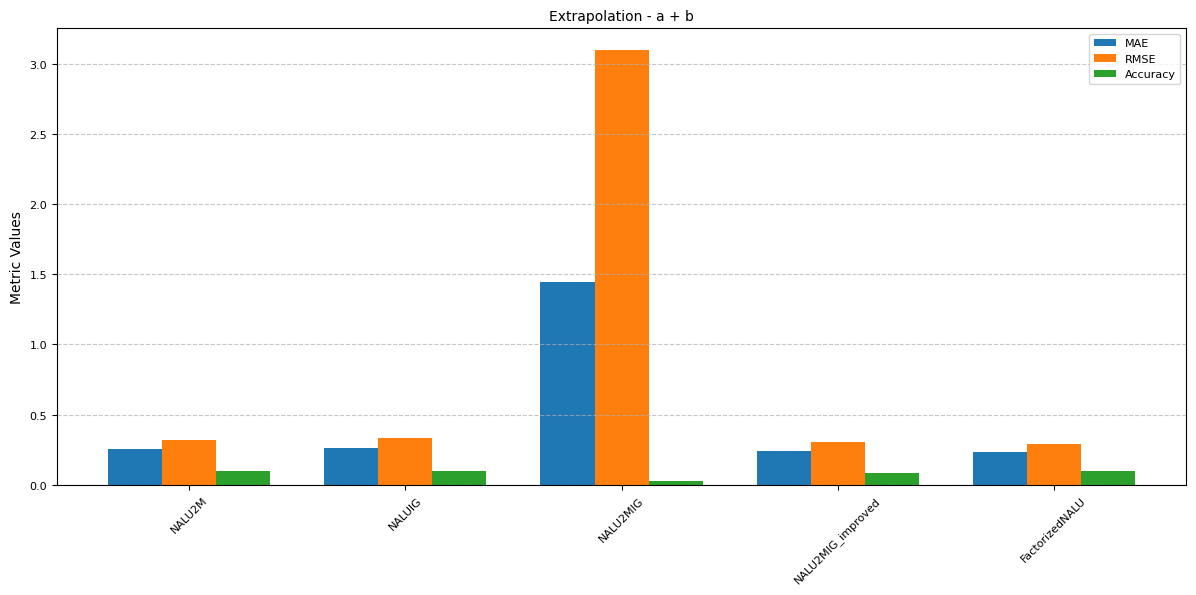

[Timing] Extrapolation plot in 0.28 seconds

### Interpolation Results
a + b
  NALU2M: MAE=0.2841 RMSE=0.3578 Acc=0.20
  NALUIG: MAE=0.3257 RMSE=0.4002 Acc=0.20
  NALU2MIG: MAE=1.8334 RMSE=6.0324 Acc=0.20
  NALU2MIG_improved: MAE=0.2724 RMSE=0.3420 Acc=0.20
  FactorizedNALU: MAE=0.2522 RMSE=0.3186 Acc=0.20
a - b
a x b
a ^ 2

### Extrapolation Results
a + b
  NALU2M: MAE=0.2556 RMSE=0.3215 Acc=0.17
  NALUIG: MAE=0.2631 RMSE=0.3319 Acc=0.17
  NALU2MIG: MAE=1.4445 RMSE=3.0963 Acc=0.17
  NALU2MIG_improved: MAE=0.2433 RMSE=0.3059 Acc=0.17
  FactorizedNALU: MAE=0.2316 RMSE=0.2930 Acc=0.17
a - b
a x b
a ^ 2

[Step] Loading data for operator: a - b
[load_data] Start loading data for op=a - b, scale=0.5, train_size=2000, test_size=500
[load_data] x_train/y_train generated in 0.00 seconds
a_max=7.9448, b_max=20.0387, y_max=15.8714
[Timing] Data loaded in 0.14 seconds
[Step] Calculating random baseline...
[Timing] Baseline calculated in 0.20 seconds

[Step] Training NALU2M on a - b...
[Params] NA

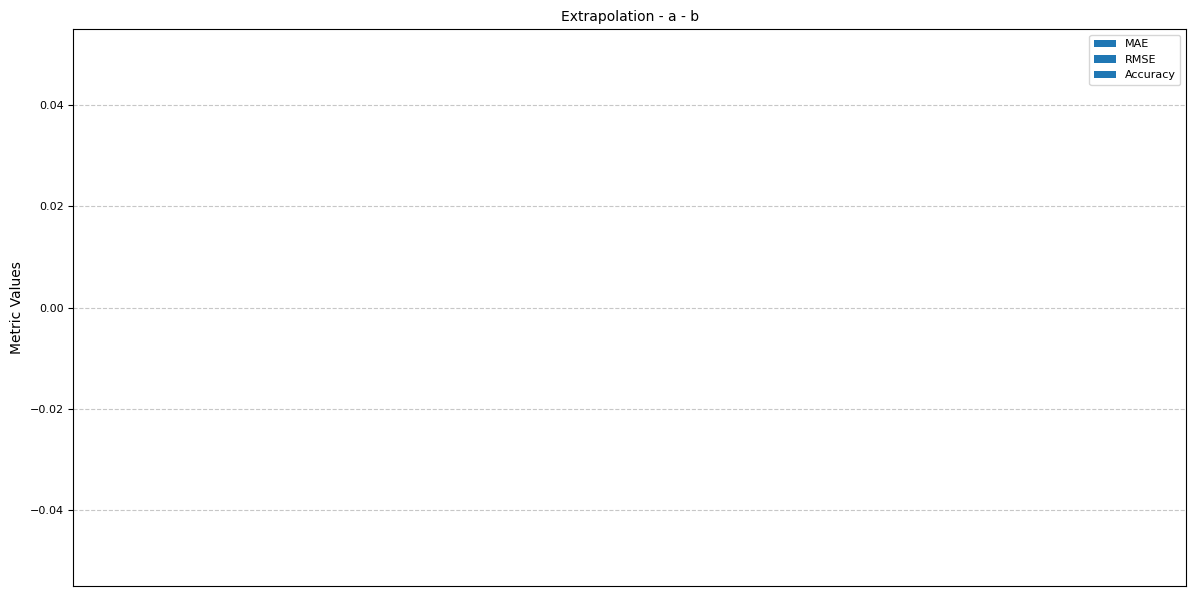

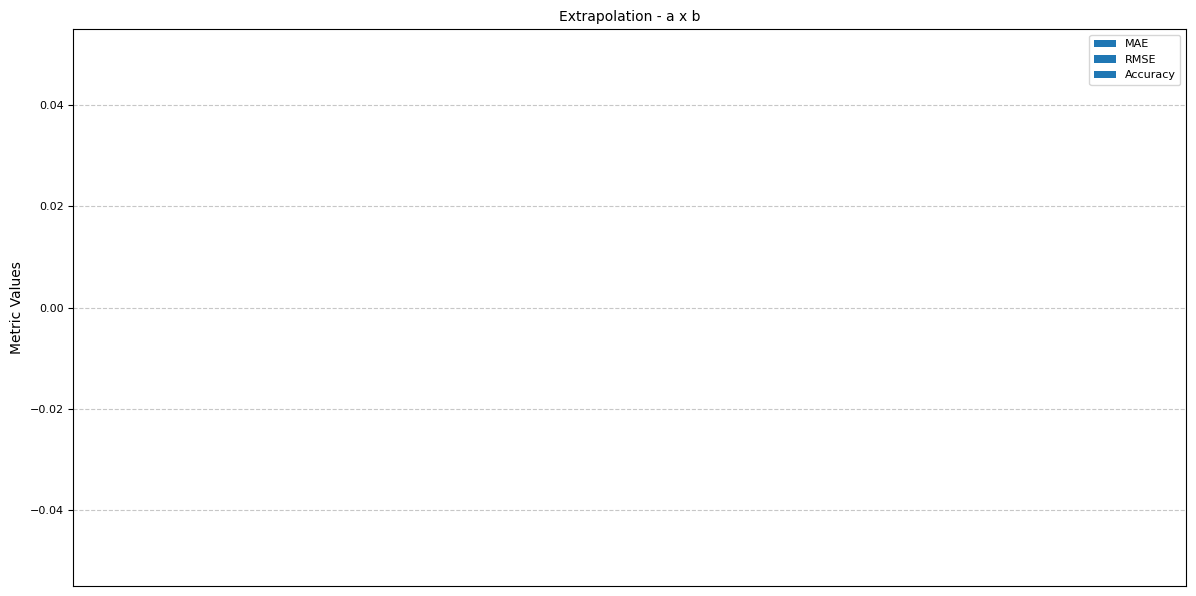

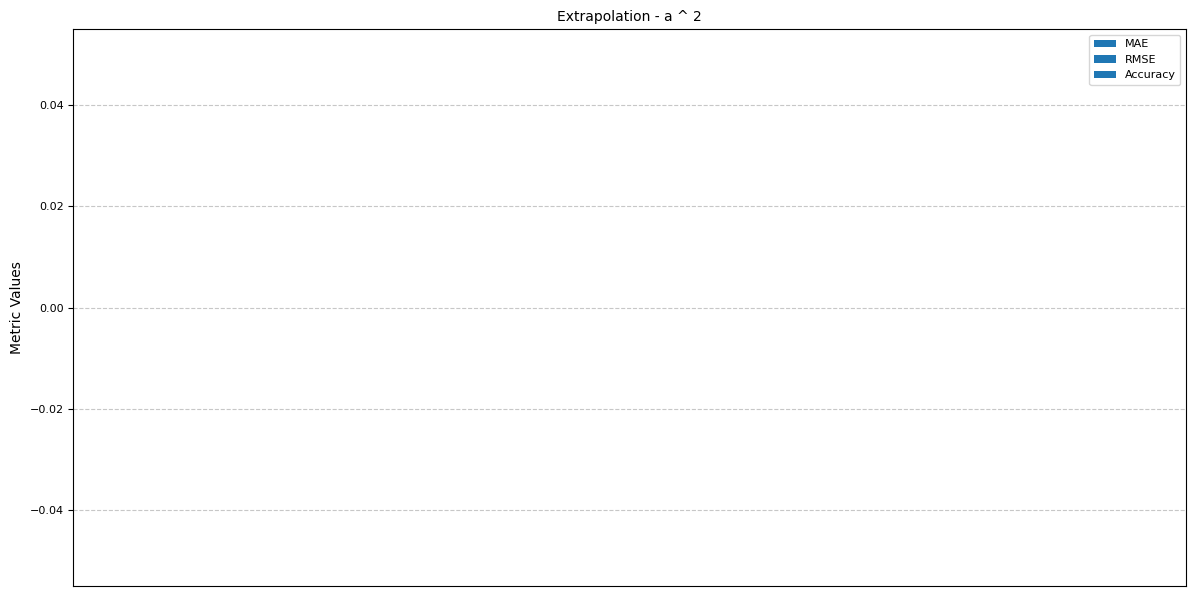

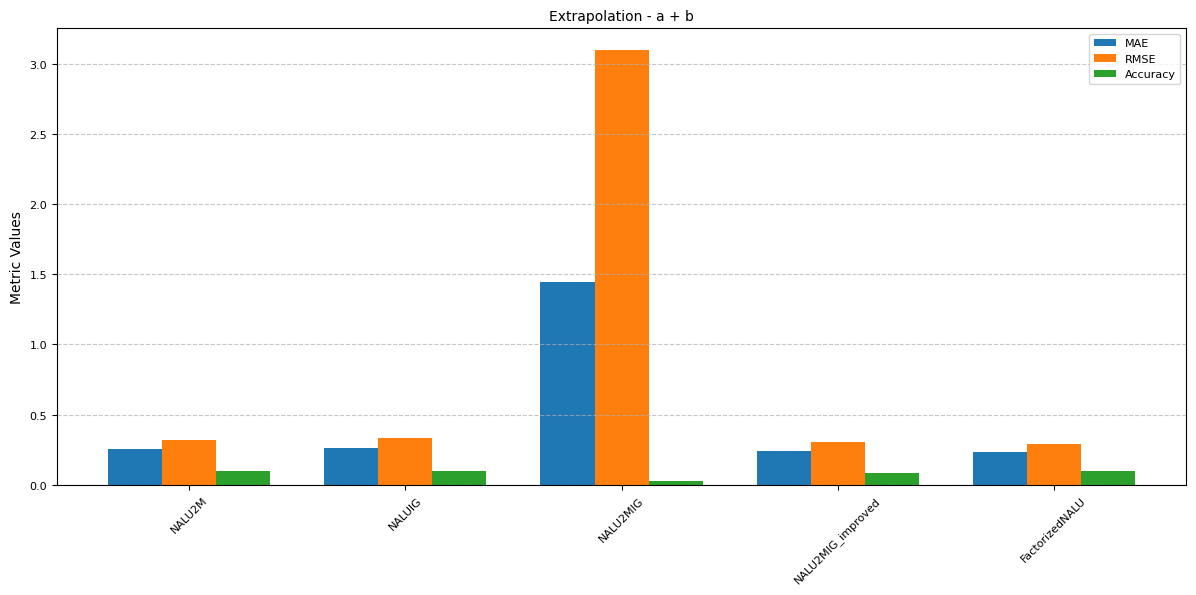

[NALU2M] Training time for a - b: 0.10988736152648926
[NALUIG] Training time for a - b: 0.11645698547363281
[NALU2MIG] Training time for a - b: 0.1365957260131836
[NALU2MIG_improved] Training time for a - b: 0.1417684555053711
[FactorizedNALU] Training time for a - b: 0.14345383644104004


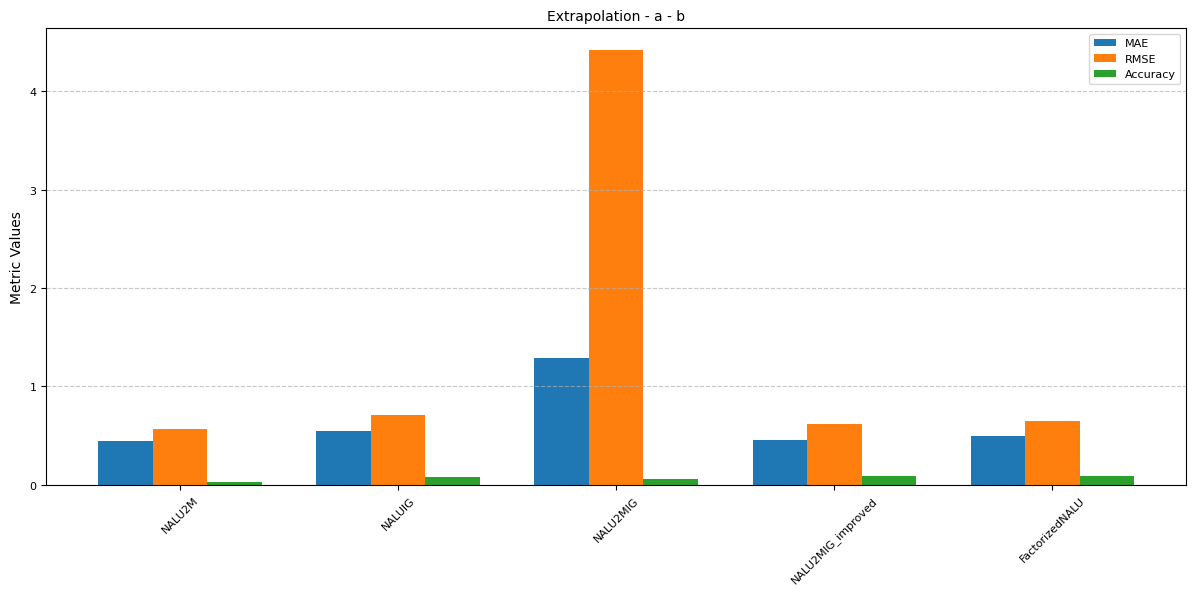

[Timing] Extrapolation plot in 0.86 seconds

### Interpolation Results
a + b
  NALU2M: MAE=0.2841 RMSE=0.3578 Acc=0.20
  NALUIG: MAE=0.3257 RMSE=0.4002 Acc=0.20
  NALU2MIG: MAE=1.8334 RMSE=6.0324 Acc=0.20
  NALU2MIG_improved: MAE=0.2724 RMSE=0.3420 Acc=0.20
  FactorizedNALU: MAE=0.2522 RMSE=0.3186 Acc=0.20
a - b
  NALU2M: MAE=0.3954 RMSE=0.5012 Acc=0.33
  NALUIG: MAE=0.4928 RMSE=0.6233 Acc=0.33
  NALU2MIG: MAE=1.1434 RMSE=2.0700 Acc=0.33
  NALU2MIG_improved: MAE=0.4846 RMSE=0.6161 Acc=0.33
  FactorizedNALU: MAE=0.5054 RMSE=0.6409 Acc=0.33
a x b
a ^ 2

### Extrapolation Results
a + b
  NALU2M: MAE=0.2556 RMSE=0.3215 Acc=0.17
  NALUIG: MAE=0.2631 RMSE=0.3319 Acc=0.17
  NALU2MIG: MAE=1.4445 RMSE=3.0963 Acc=0.17
  NALU2MIG_improved: MAE=0.2433 RMSE=0.3059 Acc=0.17
  FactorizedNALU: MAE=0.2316 RMSE=0.2930 Acc=0.17
a - b
  NALU2M: MAE=0.4459 RMSE=0.5691 Acc=0.31
  NALUIG: MAE=0.5439 RMSE=0.7141 Acc=0.31
  NALU2MIG: MAE=1.2914 RMSE=4.4169 Acc=0.31
  NALU2MIG_improved: MAE=0.4583 RMSE=0.6175 A

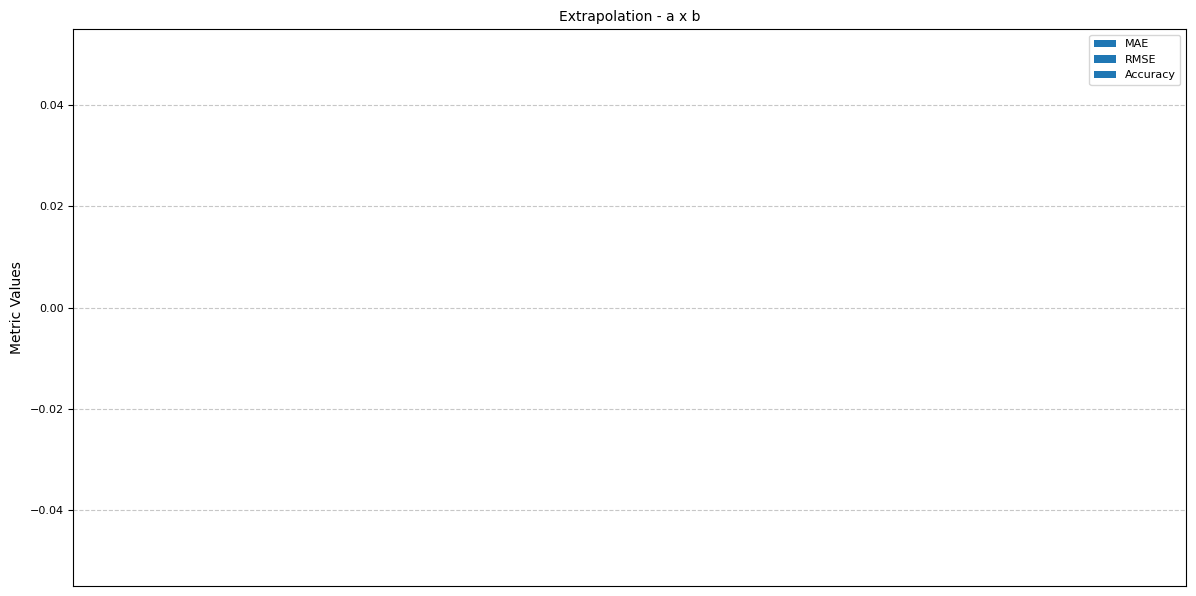

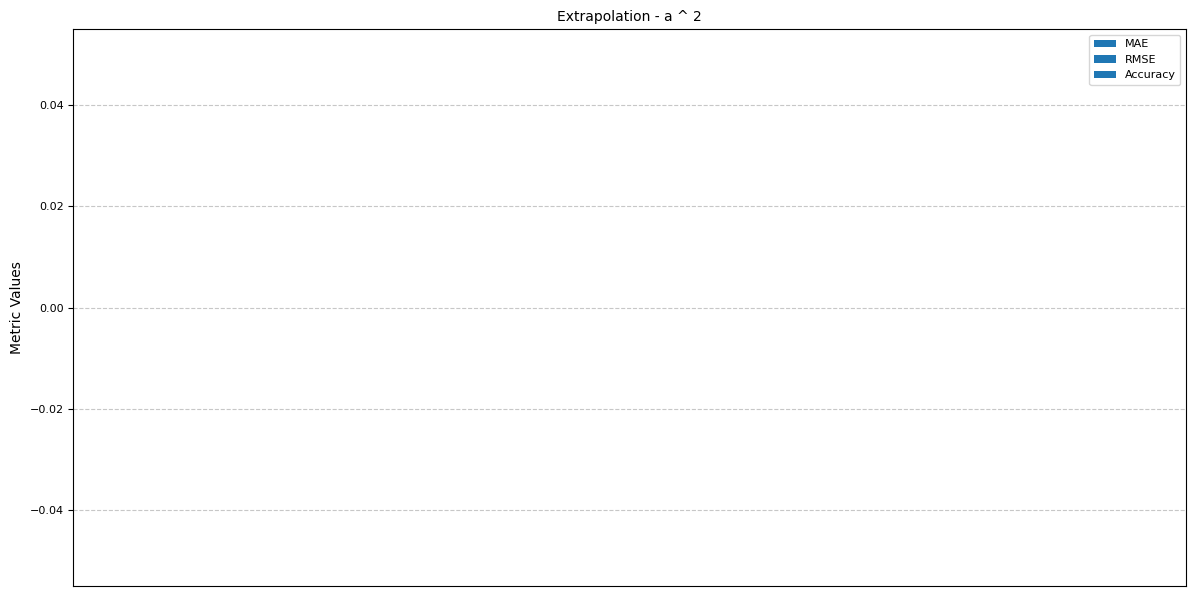

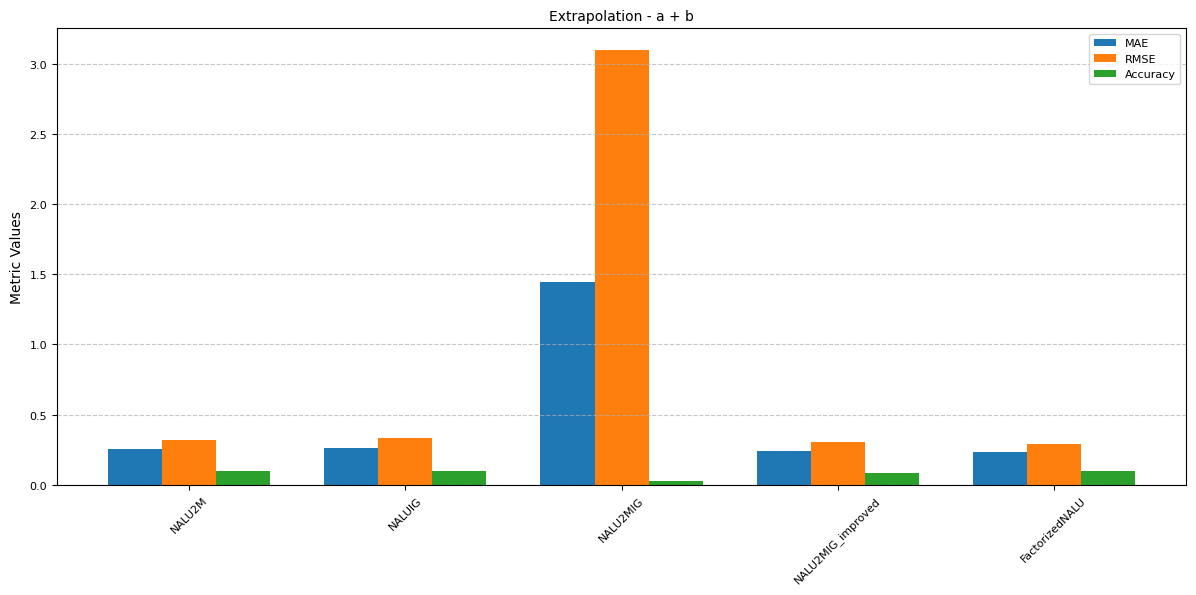

[NALU2M] Training time for a - b: 0.10988736152648926
[NALUIG] Training time for a - b: 0.11645698547363281
[NALU2MIG] Training time for a - b: 0.1365957260131836
[NALU2MIG_improved] Training time for a - b: 0.1417684555053711
[FactorizedNALU] Training time for a - b: 0.14345383644104004


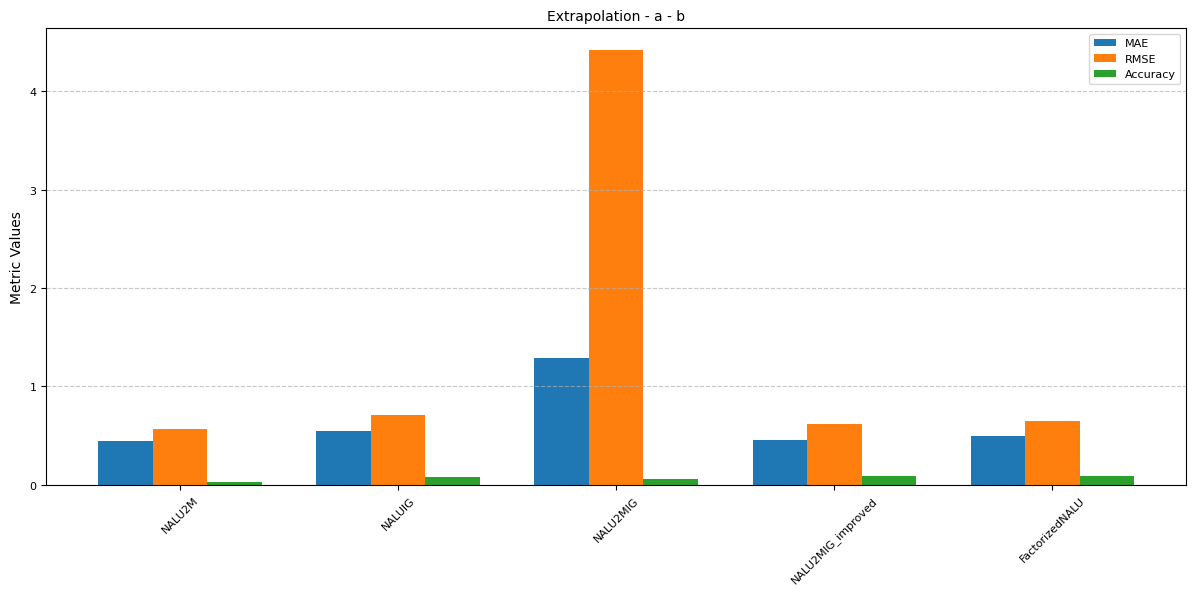

[NALU2M] Training time for a x b: 0.12152099609375
[NALUIG] Training time for a x b: 0.13980436325073242
[NALU2MIG] Training time for a x b: 0.17060327529907227
[NALU2MIG_improved] Training time for a x b: 0.16888213157653809
[FactorizedNALU] Training time for a x b: 0.15972328186035156


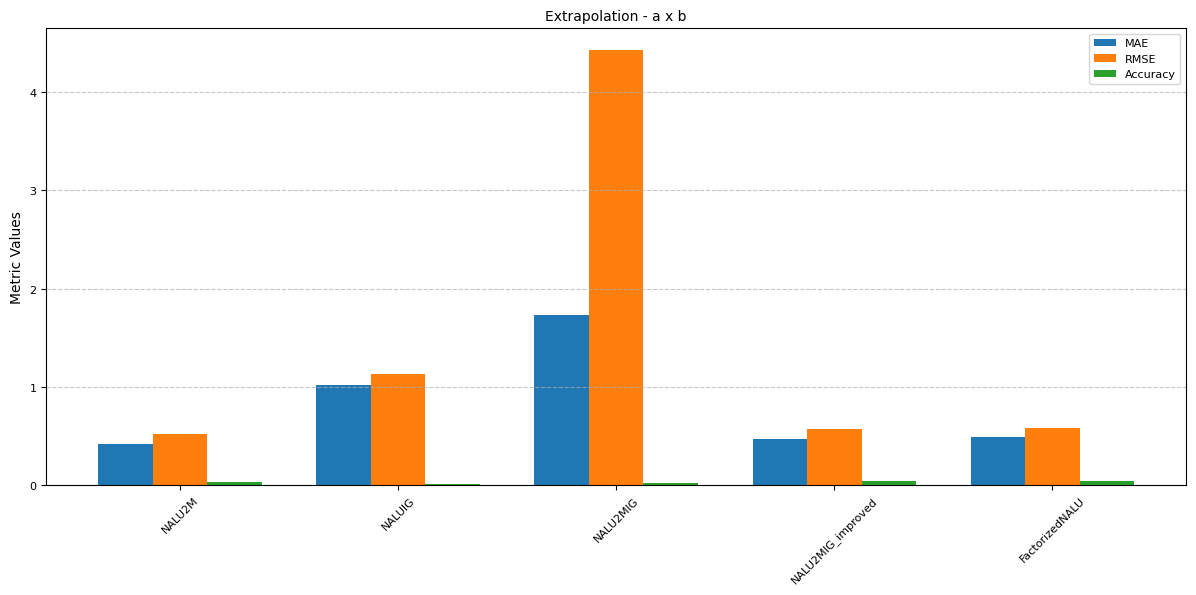

[Timing] Extrapolation plot in 1.18 seconds

### Interpolation Results
a + b
  NALU2M: MAE=0.2841 RMSE=0.3578 Acc=0.20
  NALUIG: MAE=0.3257 RMSE=0.4002 Acc=0.20
  NALU2MIG: MAE=1.8334 RMSE=6.0324 Acc=0.20
  NALU2MIG_improved: MAE=0.2724 RMSE=0.3420 Acc=0.20
  FactorizedNALU: MAE=0.2522 RMSE=0.3186 Acc=0.20
a - b
  NALU2M: MAE=0.3954 RMSE=0.5012 Acc=0.33
  NALUIG: MAE=0.4928 RMSE=0.6233 Acc=0.33
  NALU2MIG: MAE=1.1434 RMSE=2.0700 Acc=0.33
  NALU2MIG_improved: MAE=0.4846 RMSE=0.6161 Acc=0.33
  FactorizedNALU: MAE=0.5054 RMSE=0.6409 Acc=0.33
a x b
  NALU2M: MAE=0.1010 RMSE=0.1541 Acc=0.08
  NALUIG: MAE=0.6905 RMSE=0.7083 Acc=0.08
  NALU2MIG: MAE=1.4833 RMSE=4.4376 Acc=0.08
  NALU2MIG_improved: MAE=0.5606 RMSE=0.6618 Acc=0.08
  FactorizedNALU: MAE=0.5125 RMSE=0.6048 Acc=0.08
a ^ 2

### Extrapolation Results
a + b
  NALU2M: MAE=0.2556 RMSE=0.3215 Acc=0.17
  NALUIG: MAE=0.2631 RMSE=0.3319 Acc=0.17
  NALU2MIG: MAE=1.4445 RMSE=3.0963 Acc=0.17
  NALU2MIG_improved: MAE=0.2433 RMSE=0.3059 Acc=0.1

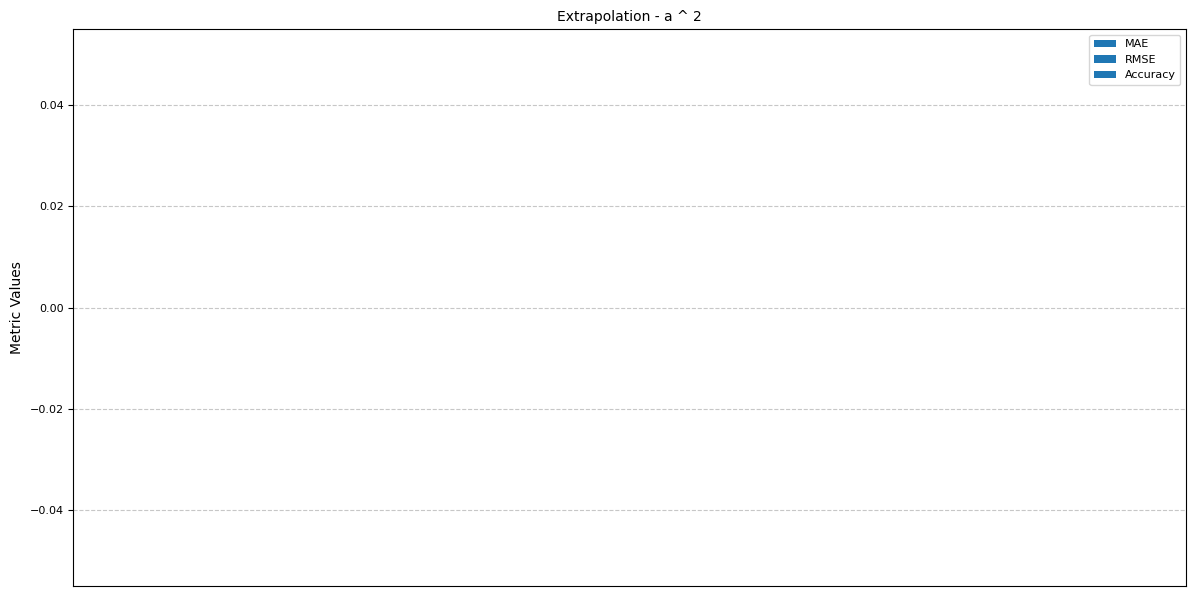

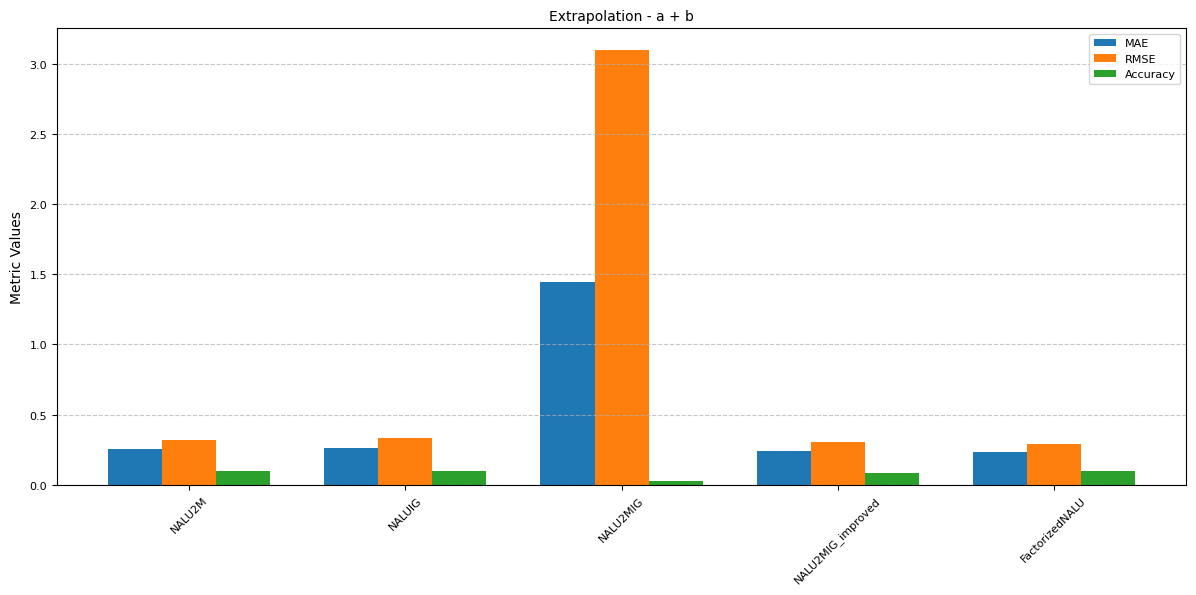

[NALU2M] Training time for a - b: 0.10988736152648926
[NALUIG] Training time for a - b: 0.11645698547363281
[NALU2MIG] Training time for a - b: 0.1365957260131836
[NALU2MIG_improved] Training time for a - b: 0.1417684555053711
[FactorizedNALU] Training time for a - b: 0.14345383644104004


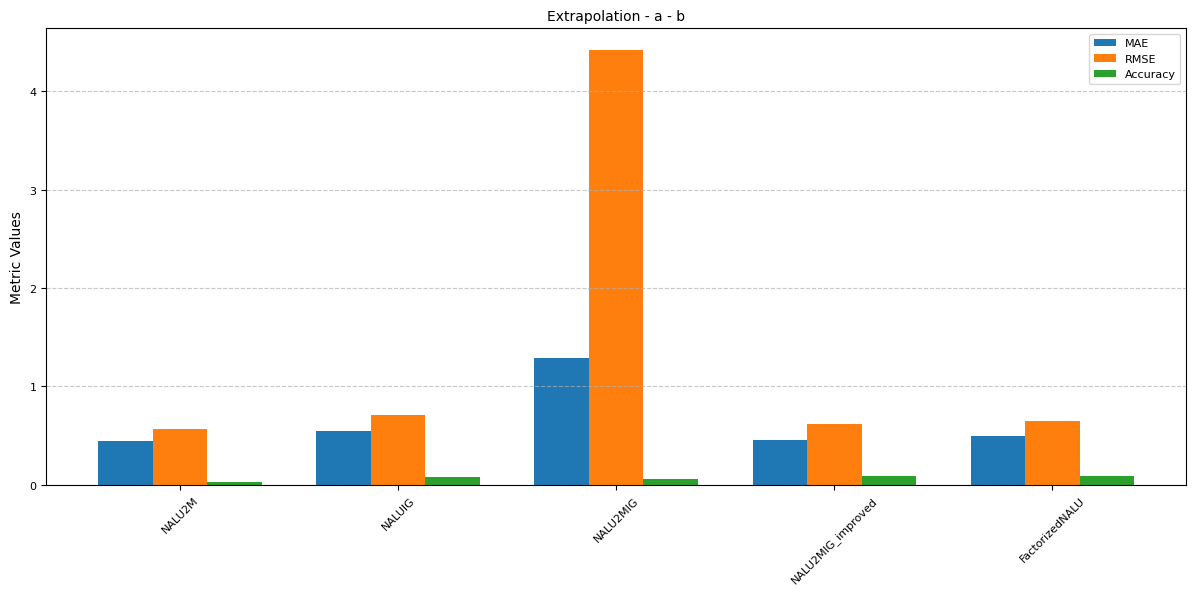

[NALU2M] Training time for a x b: 0.12152099609375
[NALUIG] Training time for a x b: 0.13980436325073242
[NALU2MIG] Training time for a x b: 0.17060327529907227
[NALU2MIG_improved] Training time for a x b: 0.16888213157653809
[FactorizedNALU] Training time for a x b: 0.15972328186035156


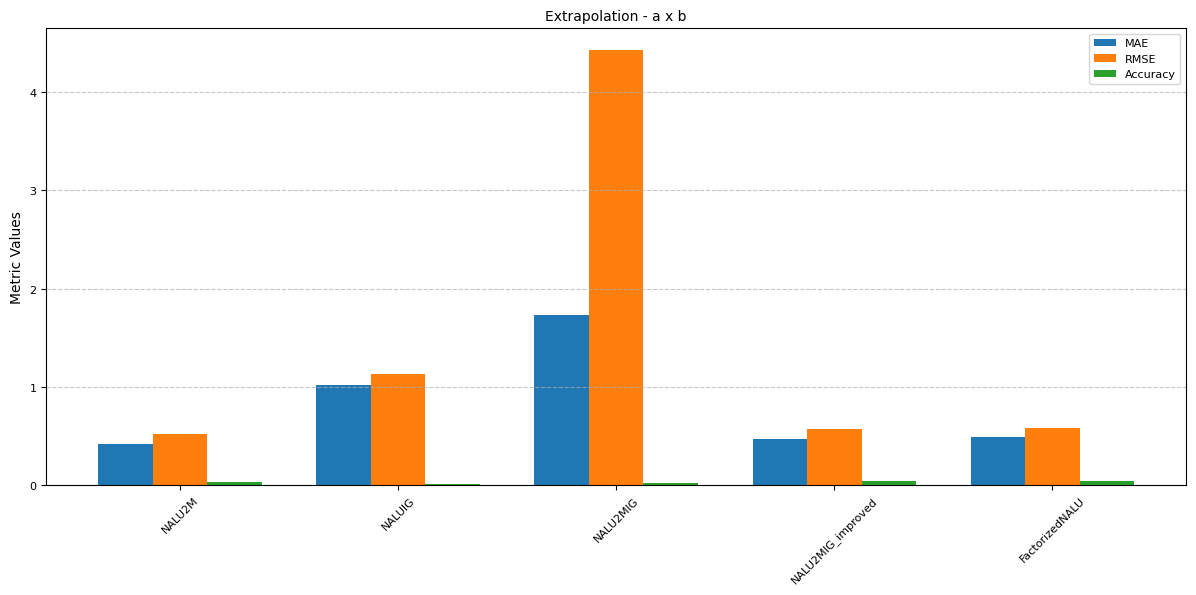

[NALU2M] Training time for a ^ 2: 0.16813969612121582
[NALUIG] Training time for a ^ 2: 0.15330958366394043
[NALU2MIG] Training time for a ^ 2: 0.16196274757385254
[NALU2MIG_improved] Training time for a ^ 2: 0.16510319709777832
[FactorizedNALU] Training time for a ^ 2: 0.17554092407226562


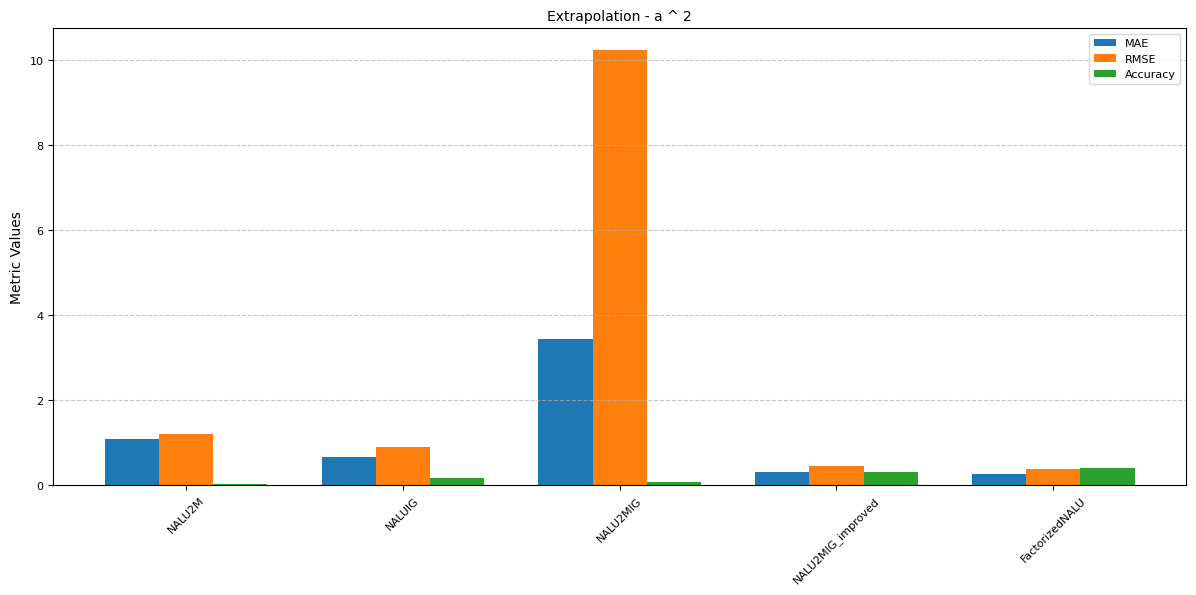

[Timing] Extrapolation plot in 1.36 seconds

### Interpolation Results
a + b
  NALU2M: MAE=0.2841 RMSE=0.3578 Acc=0.20
  NALUIG: MAE=0.3257 RMSE=0.4002 Acc=0.20
  NALU2MIG: MAE=1.8334 RMSE=6.0324 Acc=0.20
  NALU2MIG_improved: MAE=0.2724 RMSE=0.3420 Acc=0.20
  FactorizedNALU: MAE=0.2522 RMSE=0.3186 Acc=0.20
a - b
  NALU2M: MAE=0.3954 RMSE=0.5012 Acc=0.33
  NALUIG: MAE=0.4928 RMSE=0.6233 Acc=0.33
  NALU2MIG: MAE=1.1434 RMSE=2.0700 Acc=0.33
  NALU2MIG_improved: MAE=0.4846 RMSE=0.6161 Acc=0.33
  FactorizedNALU: MAE=0.5054 RMSE=0.6409 Acc=0.33
a x b
  NALU2M: MAE=0.1010 RMSE=0.1541 Acc=0.08
  NALUIG: MAE=0.6905 RMSE=0.7083 Acc=0.08
  NALU2MIG: MAE=1.4833 RMSE=4.4376 Acc=0.08
  NALU2MIG_improved: MAE=0.5606 RMSE=0.6618 Acc=0.08
  FactorizedNALU: MAE=0.5125 RMSE=0.6048 Acc=0.08
a ^ 2
  NALU2M: MAE=0.3735 RMSE=0.5795 Acc=0.14
  NALUIG: MAE=0.2656 RMSE=0.3844 Acc=0.14
  NALU2MIG: MAE=10.0643 RMSE=60.9708 Acc=0.14
  NALU2MIG_improved: MAE=0.5376 RMSE=0.6807 Acc=0.14
  FactorizedNALU: MAE=0.4763 

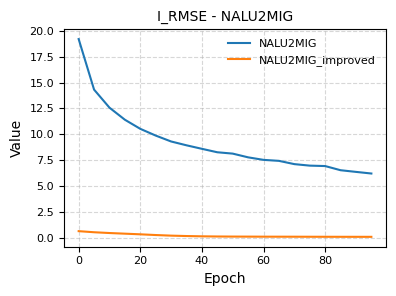

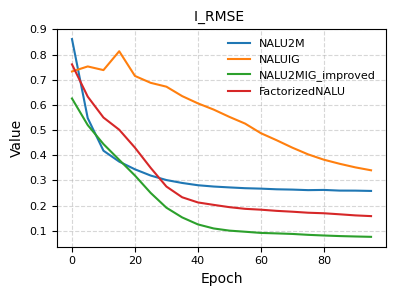

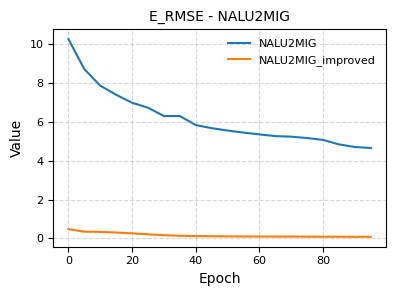

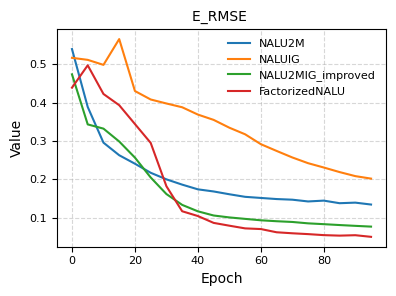

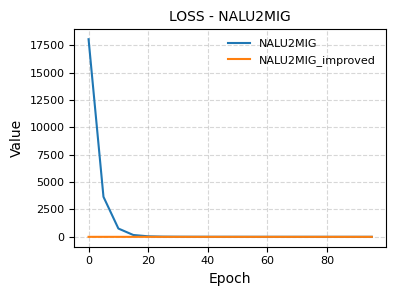

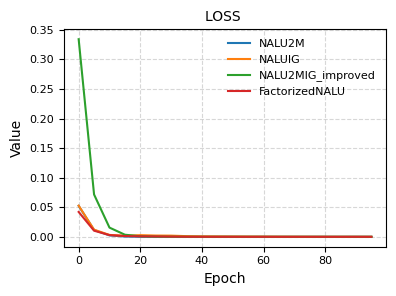

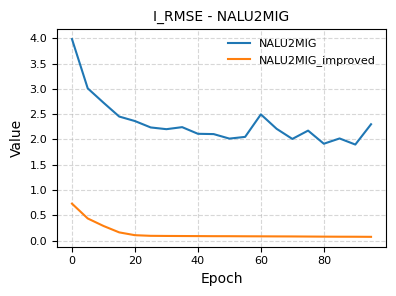

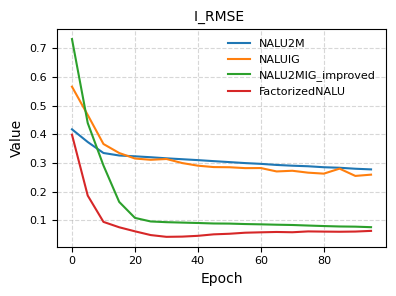

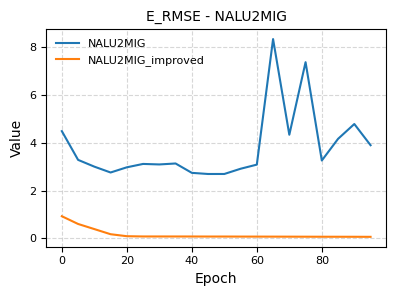

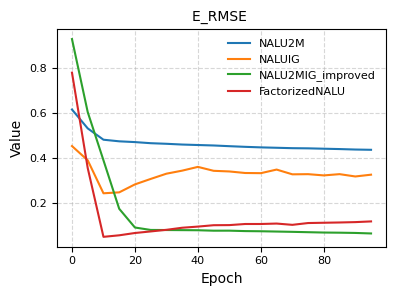

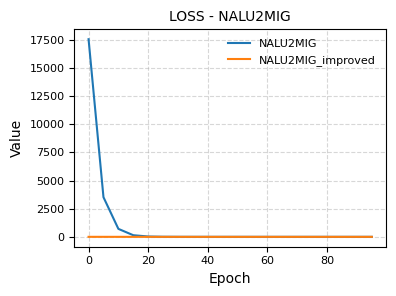

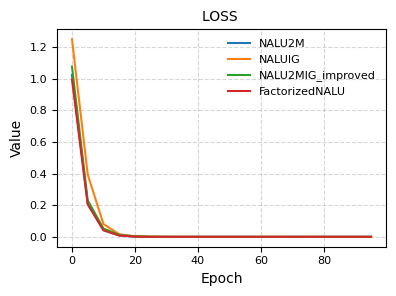

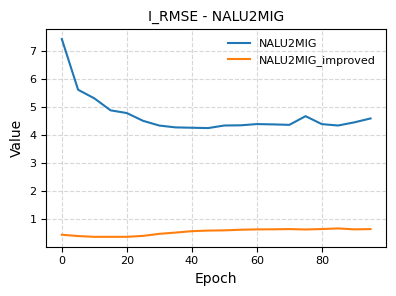

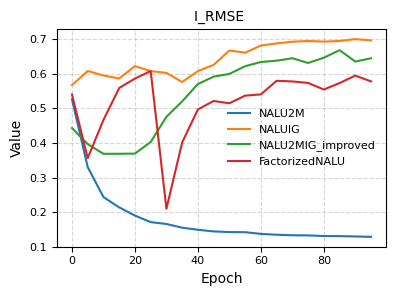

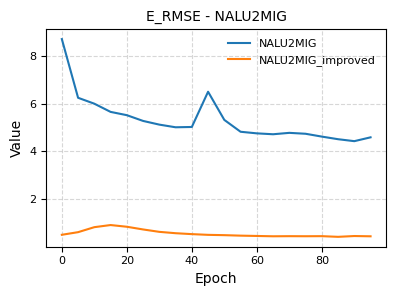

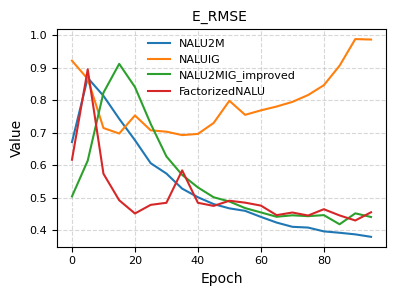

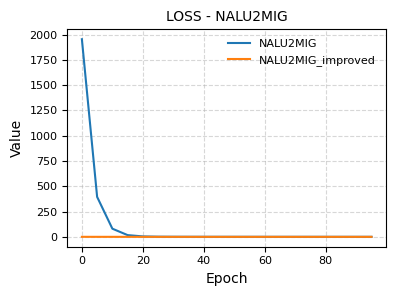

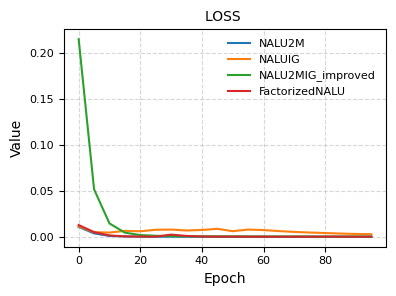

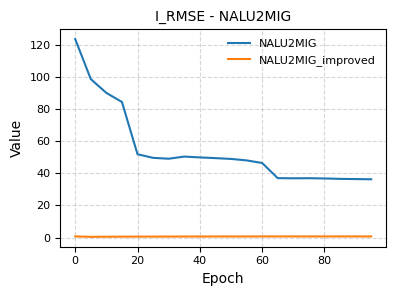

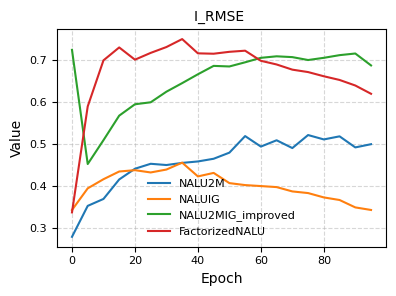

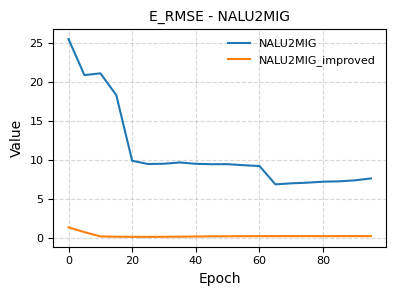

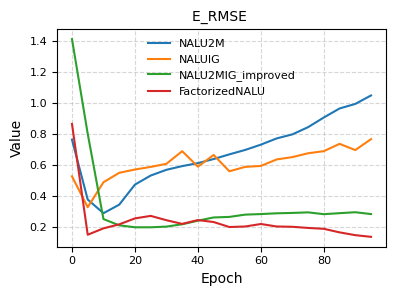

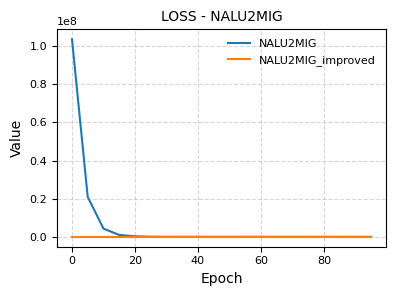

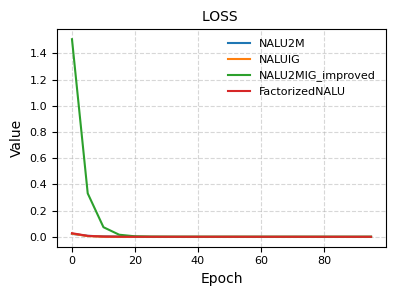

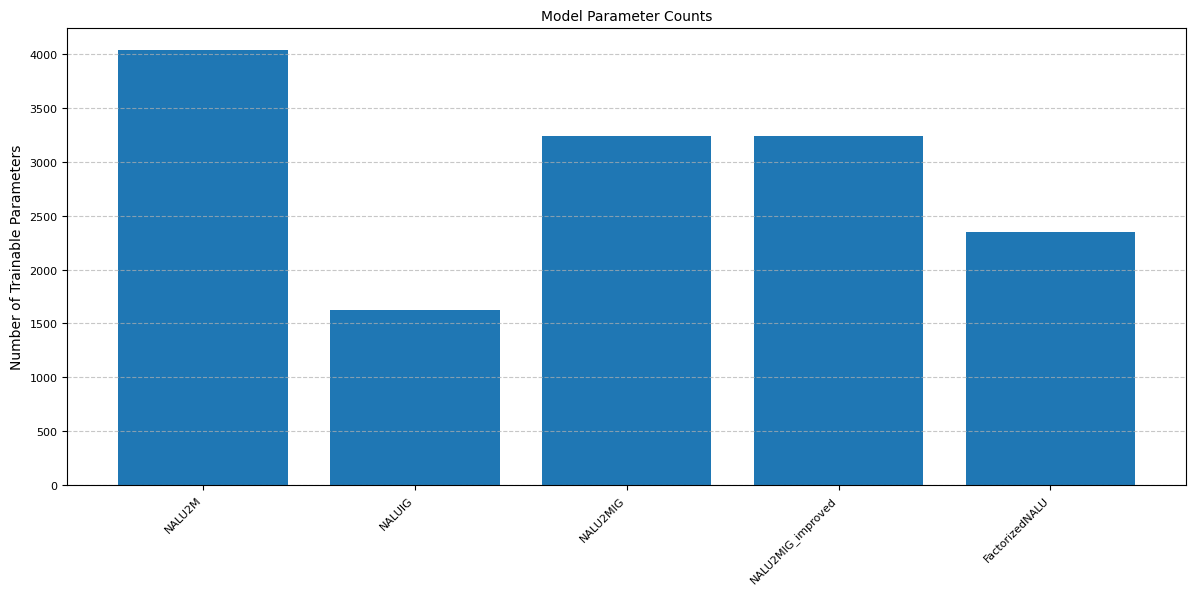

In [112]:
run_experiment()

In [113]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
import numpy as np


class SharedNALU(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()
        self.W_hat = nn.Parameter(torch.Tensor(in_features, out_features))
        self.M_hat = nn.Parameter(torch.Tensor(in_features, out_features))
        self.G = nn.Parameter(torch.Tensor(out_features))  # Independent gate
        self.eps = 1e-7
        self.reset_parameters()

    def reset_parameters(self):
        nn.init.uniform_(self.W_hat, -1e-2, 1e-2)
        nn.init.uniform_(self.M_hat, -1e-2, 1e-2)
        nn.init.uniform_(self.G, -1e-2, 1e-2)

    def forward(self, x):
        W = torch.tanh(self.W_hat) * torch.sigmoid(self.M_hat)  # Effective weight
        g = torch.sigmoid(self.G).unsqueeze(0)  # shape [1, out_features]

        a = torch.matmul(x, W)
        m = torch.exp(torch.matmul(torch.log(torch.abs(x) + self.eps), W))

        return g * a + (1 - g) * m


class FactorizedNALU(nn.Module):
    def __init__(self, in_features, out_features, rank=10):
        super().__init__()
        self.U = nn.Linear(in_features, rank, bias=False)
        self.V = nn.Linear(rank, out_features, bias=False)
        self.G = nn.Parameter(torch.Tensor(out_features))  # Independent gate
        self.eps = 1e-7
        self.reset_parameters()

    def reset_parameters(self):
        nn.init.uniform_(self.U.weight, -1e-2, 1e-2)
        nn.init.uniform_(self.V.weight, -1e-2, 1e-2)
        nn.init.uniform_(self.G, -1e-2, 1e-2)

    def forward(self, x):
        g = torch.sigmoid(self.G).unsqueeze(0)  # shape [1, out_features]
        a = self.V(self.U(x))
        log_x = torch.log(torch.abs(x) + self.eps)
        m = torch.exp(self.V(self.U(log_x)))
        return g * a + (1 - g) * m


class NMU(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()
        self.mask_logits = nn.Parameter(torch.Tensor(out_features, in_features))
        self.reset_parameters()

    def reset_parameters(self):
        nn.init.constant_(self.mask_logits, 0.0)

    def forward(self, x):
        mask = torch.sigmoid(self.mask_logits)  # shape [out_features, in_features]
        x = x.unsqueeze(1)  # shape [batch, 1, in_features]
        masked_x = x * mask.unsqueeze(0) + (1 - mask.unsqueeze(0))  # mask applied
        prod = torch.prod(masked_x, dim=-1)  # product across features
        return prod  # shape [batch, out_features]


class HybridArithmeticLayer(nn.Module):
    def __init__(self, in_features, out_features, rank=10):
        super().__init__()
        self.add_path = FactorizedNALU(in_features, out_features, rank=rank)
        self.mul_path = NMU(in_features, out_features)
        self.gate = nn.Parameter(torch.Tensor(out_features))
        self.reset_parameters()

    def reset_parameters(self):
        nn.init.uniform_(self.gate, -1e-2, 1e-2)

    def forward(self, x):
        g = torch.sigmoid(self.gate).unsqueeze(0)  # shape [1, out_features]
        a = self.add_path(x)
        m = self.mul_path(x)
        return g * a + (1 - g) * m


# Example usage in a model
def create_model(in_features=100, hidden_dim=2, out_features=1):
    return nn.Sequential(
        HybridArithmeticLayer(in_features, hidden_dim),
        HybridArithmeticLayer(hidden_dim, out_features)
    )


def train_model(model, x_train, y_train, x_test, y_test, n_epochs=100, batch_size=64, lr=1e-2):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    train_dataset = DataLoader(TensorDataset(x_train, y_train), batch_size=batch_size, shuffle=True)
    test_dataset = DataLoader(TensorDataset(x_test, y_test), batch_size=batch_size)

    train_losses = []
    test_losses = []

    for epoch in range(n_epochs):
        model.train()
        running_loss = 0.0
        for xb, yb in train_dataset:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            output = model(xb)
            loss = criterion(output, yb)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * xb.size(0)

        model.eval()
        test_loss = 0.0
        with torch.no_grad():
            for xb, yb in test_dataset:
                xb, yb = xb.to(device), yb.to(device)
                output = model(xb)
                loss = criterion(output, yb)
                test_loss += loss.item() * xb.size(0)

        train_losses.append(running_loss / len(train_dataset.dataset))
        test_losses.append(test_loss / len(test_dataset.dataset))

        if epoch % 10 == 0:
            print(f"Epoch {epoch}, Train Loss: {train_losses[-1]:.4f}, Test Loss: {test_losses[-1]:.4f}")

    return train_losses, test_losses


def plot_losses(train_losses, test_losses):
    plt.figure(figsize=(10, 5))
    plt.plot(train_losses, label='Train Loss')
    plt.plot(test_losses, label='Test Loss')
    plt.xlabel('Epoch')
    plt.ylabel('MSE Loss')
    plt.title('Training and Test Loss over Epochs')
    plt.legend()
    plt.grid(True)
    plt.show()


# Synthetic dataset example for testing
def generate_synthetic_data(n_samples=10000, in_dim=100):
    x = torch.rand(n_samples, in_dim)
    y = torch.sum(x[:, :10], dim=1, keepdim=True)  # y = sum of first 10 inputs
    return x.float(), y.float()


# Running example
if __name__ == "__main__":
    print("heeh")
    #x_train, y_train = generate_synthetic_data(8000)
    #x_test, y_test = generate_synthetic_data(2000)

    #model = create_model()
    #train_losses, test_losses = train_model(model, x_train, y_train, x_test, y_test)
    #plot_losses(train_losses, test_losses)


heeh
